In [212]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/unsdsn/world-happiness/2015.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2017.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2019.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2018.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2016.csv


In [213]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [214]:
df15 = pd.read_csv('/kaggle/input/datasets/organizations/unsdsn/world-happiness/2015.csv')
df16 = pd.read_csv('/kaggle/input/datasets/organizations/unsdsn/world-happiness/2016.csv')
df17 = pd.read_csv('/kaggle/input/datasets/organizations/unsdsn/world-happiness/2017.csv')
df18 = pd.read_csv('/kaggle/input/datasets/organizations/unsdsn/world-happiness/2018.csv')
df19 = pd.read_csv('/kaggle/input/datasets/organizations/unsdsn/world-happiness/2019.csv')

print("\n 2015 Yılı Datası Kolonları.")
print("----------------------------------------------------------------------------------------------------------------------------------")
print(df15.columns.tolist())
print("\n 2016 Yılı Datası Kolonları.")
print("----------------------------------------------------------------------------------------------------------------------------------")
print(df16.columns.tolist())
print("\n 2017 Yılı Datası Kolonları.")
print("----------------------------------------------------------------------------------------------------------------------------------")
print(df17.columns.tolist())
print("\n 2018 Yılı Datası Kolonları.")
print("----------------------------------------------------------------------------------------------------------------------------------")
print(df18.columns.tolist())
print("\n 2019 Yılı Datası Kolonları.")
print("----------------------------------------------------------------------------------------------------------------------------------")
print(df19.columns.tolist())


 2015 Yılı Datası Kolonları.
----------------------------------------------------------------------------------------------------------------------------------
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

 2016 Yılı Datası Kolonları.
----------------------------------------------------------------------------------------------------------------------------------
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

 2017 Yılı Datası Kolonları.
----------------------------------------------------------------------------------------------------------------------------------
['Country', 'Happiness.Rank', 'Ha

In [215]:
df17.rename(columns={

    "Happiness.Rank" : "Happiness Rank",
    "Happiness.Score" : "Happiness Score",
    "Economy..GDP.per.Capita." : "Economy (GDP per Capita)",
    "Health..Life.Expectancy." : "Health (Life Expectancy)",
    "Trust..Government.Corruption." : "Trust (Government Corruption)",
    "Dystopia.Residual" : "Dystopia Residual"
    
}, inplace=True)

In [216]:
df15.columns.to_list()

['Country',
 'Region',
 'Happiness Rank',
 'Happiness Score',
 'Standard Error',
 'Economy (GDP per Capita)',
 'Family',
 'Health (Life Expectancy)',
 'Freedom',
 'Trust (Government Corruption)',
 'Generosity',
 'Dystopia Residual']

In [217]:
df16.columns.to_list()

['Country',
 'Region',
 'Happiness Rank',
 'Happiness Score',
 'Lower Confidence Interval',
 'Upper Confidence Interval',
 'Economy (GDP per Capita)',
 'Family',
 'Health (Life Expectancy)',
 'Freedom',
 'Trust (Government Corruption)',
 'Generosity',
 'Dystopia Residual']

In [218]:
df17.columns.to_list()

['Country',
 'Happiness Rank',
 'Happiness Score',
 'Whisker.high',
 'Whisker.low',
 'Economy (GDP per Capita)',
 'Family',
 'Health (Life Expectancy)',
 'Freedom',
 'Generosity',
 'Trust (Government Corruption)',
 'Dystopia Residual']

In [219]:
df16 = df16.drop( ['Lower Confidence Interval',
 'Upper Confidence Interval'], axis = 1)
df17 = df17.drop(['Whisker.high',
 'Whisker.low'], axis = 1)
df15 = df15.drop('Standard Error', axis = 1)

df17['Region'] = 0

In [220]:
country_region = pd.concat([df15, df16])[["Country", "Region"]].drop_duplicates()

df17 = df17.drop(columns=["Region"], errors="ignore")

df17 = df17.merge(country_region, on="Country", how="left")

In [221]:
df17.head(10)

,Country,Happiness Rank,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Generosity,Trust (Government Corruption),Dystopia Residual,Region
0,Norway,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,Western Europe
1,Denmark,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,Western Europe
2,Iceland,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,Western Europe
3,Switzerland,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,Western Europe
4,Finland,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,Western Europe
5,Netherlands,6,7.377,1.503945,1.428939,0.810696,0.585384,0.470490,0.282662,2.294804,Western Europe
6,Canada,7,7.316,1.479204,1.481349,0.834558,0.611101,0.435540,0.287372,2.187264,North America
7,New Zealand,8,7.314,1.405706,1.548195,0.816760,0.614062,0.500005,0.382817,2.046456,Australia and New Zealand
8,Sweden,9,7.284,1.494387,1.478162,0.830875,0.612924,0.385399,0.384399,2.097538,Western Europe
9,Australia,10,7.284,1.484415,1.510042,0.843887,0.601607,0.477699,0.301184,2.065211,Australia and New Zealand


In [222]:
df17.isnull().sum()

Country                          0
Happiness Rank                   0
Happiness Score                  0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Generosity                       0
Trust (Government Corruption)    0
Dystopia Residual                0
Region                           2
dtype: int64

In [223]:
df17 = df17.dropna(subset='Region')

In [224]:
df = pd.concat([df15, df16, df17], ignore_index=True)

In [225]:
df.head()

,Country,Region,Happiness Rank,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        468 non-null    object 
 1   Region                         468 non-null    object 
 2   Happiness Rank                 468 non-null    int64  
 3   Happiness Score                468 non-null    float64
 4   Economy (GDP per Capita)       468 non-null    float64
 5   Family                         468 non-null    float64
 6   Health (Life Expectancy)       468 non-null    float64
 7   Freedom                        468 non-null    float64
 8   Trust (Government Corruption)  468 non-null    float64
 9   Generosity                     468 non-null    float64
 10  Dystopia Residual              468 non-null    float64
dtypes: float64(8), int64(1), object(2)
memory usage: 40.3+ KB


In [227]:
df.shape

(468, 11)

In [228]:
df.describe()

,Happiness Rank,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000
mean,78.944444,5.368265,0.925416,0.988922,0.578735,0.402728,0.134601,0.241924,2.095931
std,45.327090,1.138379,0.414804,0.318615,0.239880,0.150610,0.111259,0.131680,0.562486
min,1.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.000000,4.507750,0.602728,0.792359,0.401866,0.296487,0.059632,0.152581,1.737985
50%,79.000000,5.279000,0.994445,1.023380,0.629940,0.418347,0.099502,0.222595,2.094640
75%,118.000000,6.223250,1.251210,1.227692,0.764443,0.517385,0.172722,0.315572,2.458470
max,158.000000,7.587000,1.870766,1.610574,1.025250,0.669730,0.551910,0.838075,3.837720


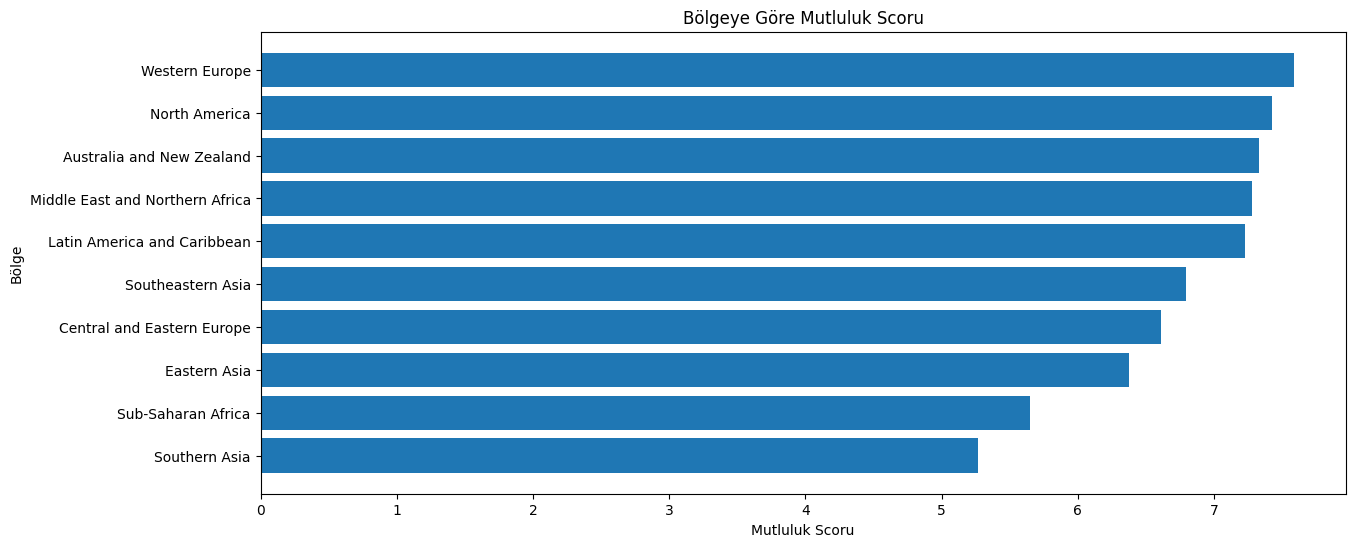

In [229]:
plt.figure(figsize=(14,6))
plt.barh(df['Region'],df['Happiness Score'])
plt.gca().invert_yaxis()
plt.title('Bölgeye Göre Mutluluk Scoru')
plt.xlabel('Mutluluk Scoru')
plt.ylabel('Bölge')
plt.show()

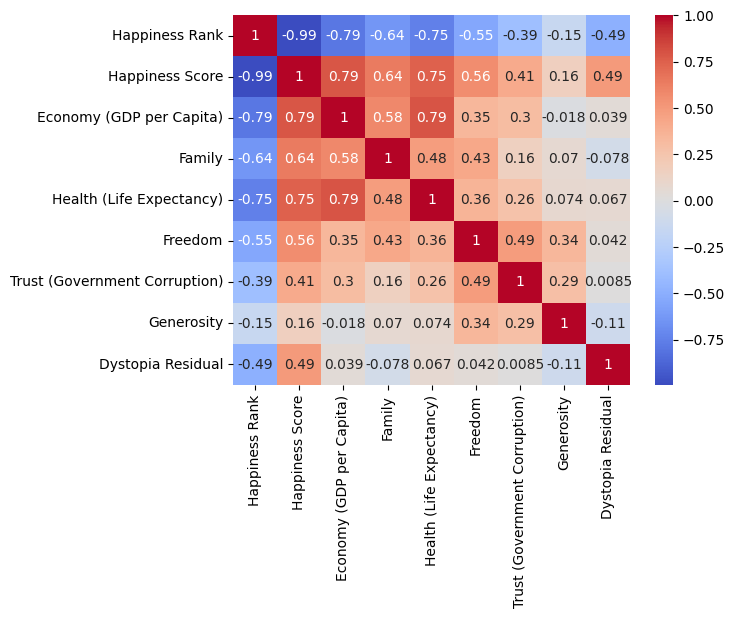

In [230]:
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.show()

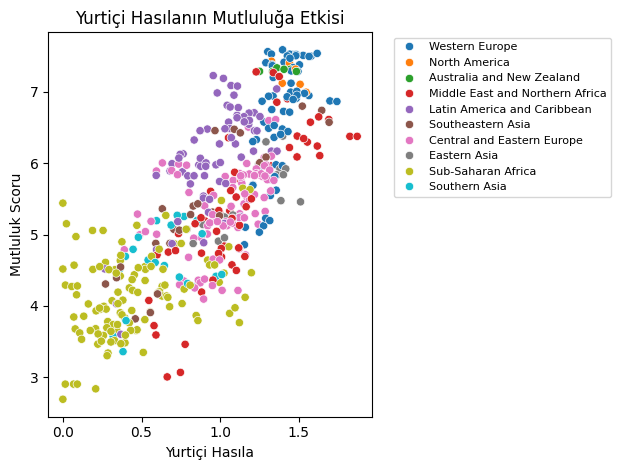

In [231]:
sns.scatterplot(data=df, x='Economy (GDP per Capita)', y='Happiness Score', hue='Region')
plt.title('Yurtiçi Hasılanın Mutluluğa Etkisi')
plt.xlabel('Yurtiçi Hasıla')
plt.ylabel('Mutluluk Scoru')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

/tmp/ipykernel_58/3608015067.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=karsilastirma, x='Happiness Score', y='Country', palette=colors)
/tmp/ipykernel_58/3608015067.py:8: UserWarning: The palette list has more values (20) than needed (10), which may not be intended.
  sns.barplot(data=karsilastirma, x='Happiness Score', y='Country', palette=colors)


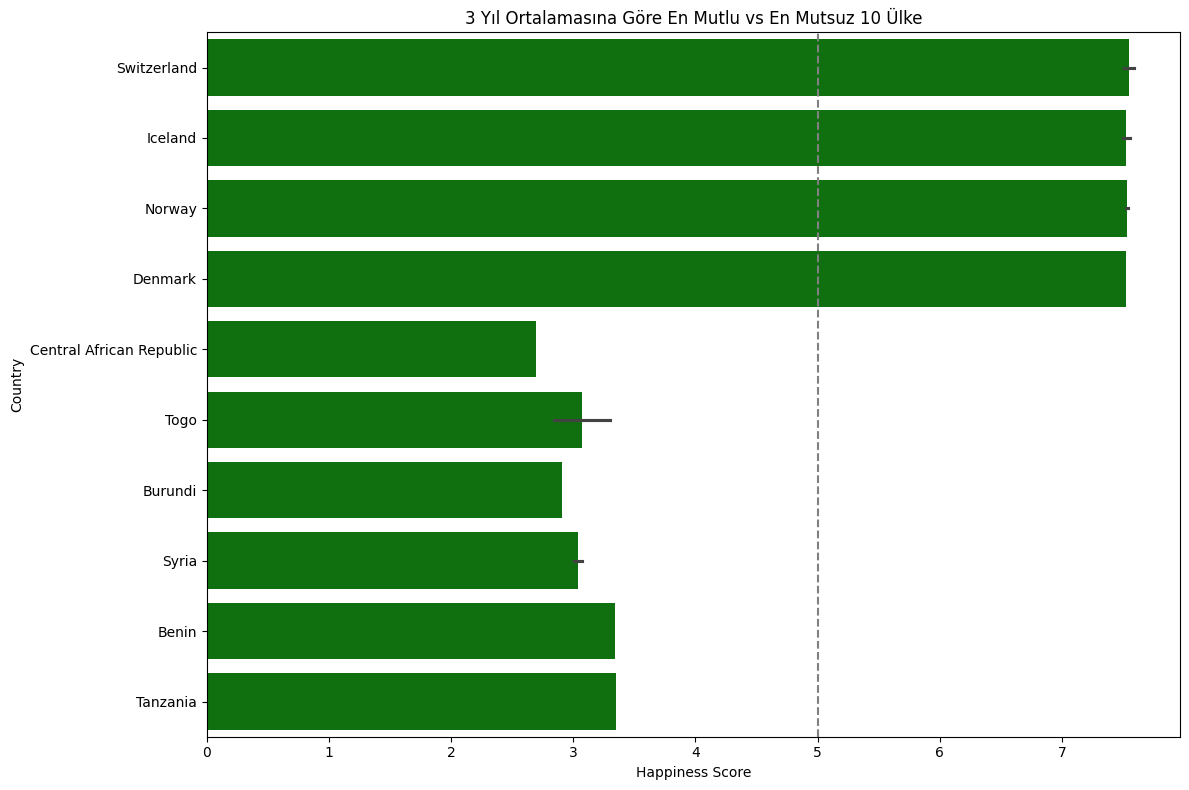

In [232]:
en_mutlu = df.nlargest(10, 'Happiness Score')
en_mutsuz = df.nsmallest(10, 'Happiness Score')

karsilastirma = pd.concat([en_mutlu, en_mutsuz])

plt.figure(figsize=(12, 8))
colors = ['green' if x > 5 else 'red' for x in karsilastirma['Happiness Score']]
sns.barplot(data=karsilastirma, x='Happiness Score', y='Country', palette=colors)
plt.axvline(x=5, color='gray', linestyle='--')
plt.title('3 Yıl Ortalamasına Göre En Mutlu vs En Mutsuz 10 Ülke')
plt.tight_layout()
plt.show()

In [233]:
df['Country'].value_counts()

Country
Switzerland          3
Iceland              3
Denmark              3
Norway               3
Canada               3
                    ..
Somaliland region    1
Djibouti             1
Swaziland            1
Puerto Rico          1
Somaliland Region    1
Name: count, Length: 164, dtype: int64

In [234]:
df['Region'].value_counts()

Region
Sub-Saharan Africa                 117
Central and Eastern Europe          87
Latin America and Caribbean         68
Western Europe                      63
Middle East and Northern Africa     58
Southeastern Asia                   26
Southern Asia                       21
Eastern Asia                        16
North America                        6
Australia and New Zealand            6
Name: count, dtype: int64

In [235]:
df.drop('Country', axis = 1, inplace=True)
df = pd.get_dummies(df, columns=['Region'], drop_first=True, dtype=int)

In [236]:
df.head()

,Happiness Rank,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Region_Central and Eastern Europe,Region_Eastern Asia,Region_Latin America and Caribbean,Region_Middle East and Northern Africa,Region_North America,Region_Southeastern Asia,Region_Southern Asia,Region_Sub-Saharan Africa,Region_Western Europe
0,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,0,0,0,0,0,0,0,0,1
1,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,0,0,0,0,0,0,0,0,1
2,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,0,0,0,0,0,0,0,0,1
3,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,0,0,0,0,0,0,0,0,1
4,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,0,0,0,0,1,0,0,0,0


In [237]:
from sklearn.model_selection import train_test_split

X = df.drop('Happiness Score', axis = 1)
y = df['Happiness Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [238]:
!pip install lazypredict

In [239]:
from lazypredict.Supervised import LazyRegressor
from sklearn.utils import shuffle

offset = int(X.shape[0] * 0.9)

X_train, y_train = X[:offset], y[:offset]
X_test, y_test = X[offset:], y[offset:]

reg = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

print(models)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


                               Adjusted R-Squared   R-Squared      RMSE  \
Model                                                                     
LassoLarsCV                              0.999999    1.000000  0.000286   
LassoLarsIC                              0.999999    1.000000  0.000287   
BayesianRidge                            0.999999    1.000000  0.000287   
RANSACRegressor                          0.999999    1.000000  0.000287   
LinearRegression                         0.999999    1.000000  0.000287   
TransformedTargetRegressor               0.999999    1.000000  0.000287   
HuberRegressor                           0.999999    1.000000  0.000294   
LarsCV                                   0.999999    0.999999  0.000331   
LinearSVR                                0.999999    0.999999  0.000416   
Lars                                     0.999993    0.999996  0.000930   
RidgeCV                                  0.999966    0.999978  0.002118   
LassoCV                  

In [240]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)


print("\nLinear Regresyon Modeli")
print("$" * 40)
print("R2 SCORU:")
print(r2)
print("MEAN ABSOLUTE ERROR")
print(mae)
print("MEAN SQUARED ERROR")
print(mse)


Linear Regresyon Modeli
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
R2 SCORU:
0.999999599683738
MEAN ABSOLUTE ERROR
0.00024692253743741305
MEAN SQUARED ERROR
8.25706040347249e-08


In [241]:
from sklearn.model_selection import GridSearchCV

params = {
    "fit_intercept": [True, False],
    "positive": [True, False],
    "n_jobs": [-1, None]  
}

grid_search = GridSearchCV(model, params, cv=5, n_jobs=-1)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(), n_jobs=-1,
             param_grid={'fit_intercept': [True, False], 'n_jobs': [-1, None],
                         'positive': [True, False]})

In [243]:
print(grid_search.best_params_)
print(grid_search.best_score_)
best_model = grid_search.best_estimator_

{'fit_intercept': False, 'n_jobs': -1, 'positive': True}
0.9999998366837541
